c:\Users\Windows 11\Downloads
Epoch 01 | Train Loss: 0.6527 | Val Loss: 0.6458 | Train Acc: 0.6449 | Val Acc: 0.6678
Epoch 02 | Train Loss: 0.6452 | Val Loss: 0.6385 | Train Acc: 0.6655 | Val Acc: 0.6891
Epoch 03 | Train Loss: 0.6379 | Val Loss: 0.6312 | Train Acc: 0.6864 | Val Acc: 0.7121
Epoch 04 | Train Loss: 0.6307 | Val Loss: 0.6241 | Train Acc: 0.7051 | Val Acc: 0.7301
Epoch 05 | Train Loss: 0.6235 | Val Loss: 0.6170 | Train Acc: 0.7246 | Val Acc: 0.7449
Epoch 06 | Train Loss: 0.6164 | Val Loss: 0.6100 | Train Acc: 0.7429 | Val Acc: 0.7588
Epoch 07 | Train Loss: 0.6094 | Val Loss: 0.6032 | Train Acc: 0.7603 | Val Acc: 0.7760
Epoch 08 | Train Loss: 0.6025 | Val Loss: 0.5964 | Train Acc: 0.7781 | Val Acc: 0.7900
Epoch 09 | Train Loss: 0.5957 | Val Loss: 0.5897 | Train Acc: 0.7928 | Val Acc: 0.8113
Epoch 10 | Train Loss: 0.5890 | Val Loss: 0.5832 | Train Acc: 0.8067 | Val Acc: 0.8228
Epoch 11 | Train Loss: 0.5824 | Val Loss: 0.5767 | Train Acc: 0.8199 | Val Acc: 0.8351
Epoch 12 | Tr

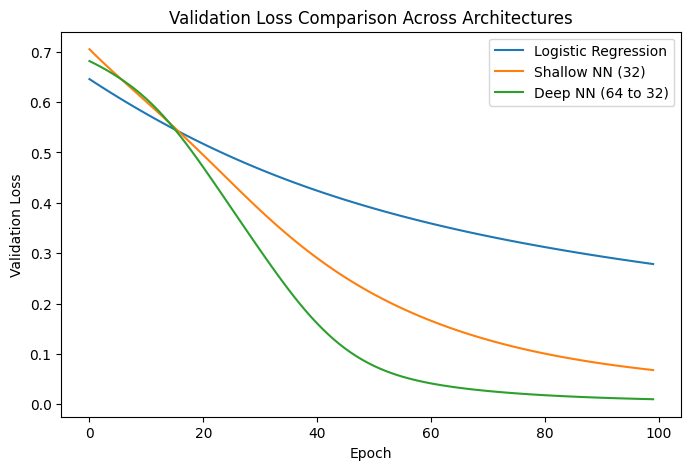

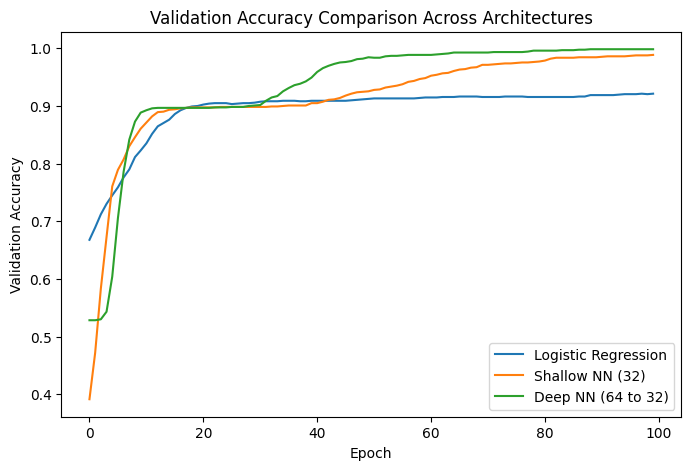


Logistic Regression Test Accuracy: 0.9139


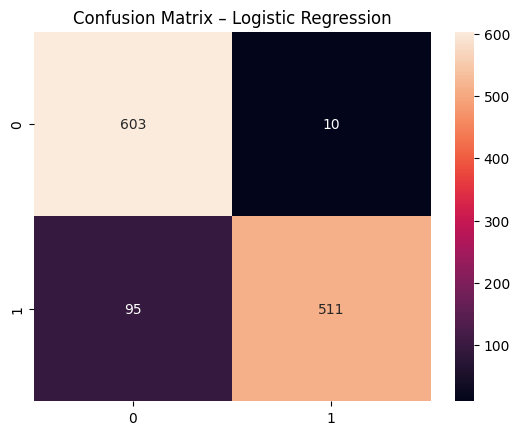


Shallow NN (32) Test Accuracy: 0.9902


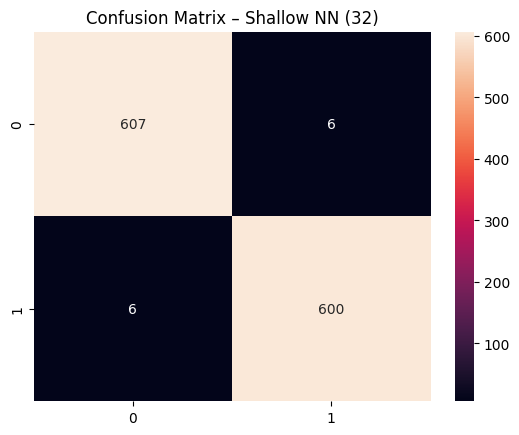


Deep NN (64 to 32) Test Accuracy: 1.0000


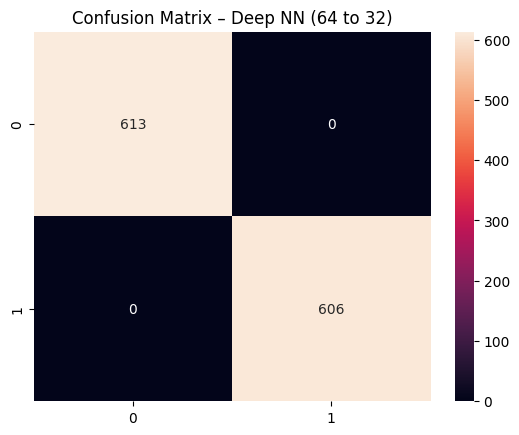

In [ ]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import os
print(os.getcwd())

# data

columns = [
    "class",
    "cap_shape",
    "cap_surface",
    "cap_color",
    "bruises",
    "odor",
    "gill_attachment",
    "gill_spacing",
    "gill_size",
    "gill_color",
    "stalk_shape",
    "stalk_root",
    "stalk_surface_above_ring",
    "stalk_surface_below_ring",
    "stalk_color_above_ring",
    "stalk_color_below_ring",
    "veil_type",
    "veil_color",
    "ring_number",
    "ring_type",
    "spore_print_color",
    "population",
    "habitat"
]

df = pd.read_csv("C:/Users/Windows 11/Downloads/mushroom/agaricus-lepiota.data", header = None, names=columns)
#df = pd.read_csv("agaricus-lepiota.data", header = None, names=columns)

df.replace("?", "missing", inplace=True)

X = pd.get_dummies(df.drop("class", axis=1))
y = df["class"].map({"e": 0, "p": 1}).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50)

X_train = torch.tensor(X_train.values, dtype=torch.float32)
#X_train = torch.tensor(X_train.values, dtype=torch.float)
X_val = torch.tensor(X_val.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)



# All the architectures 
class ShallowNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)


class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)

            # nn.Linear(input_dim, 64),
            # nn.ReLU(),
            # nn.Linear(64, 32),
            # nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)


class LogisticRegression(nn.Module): #(Linear + sigmoid activation function )
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.linear(x)

# training and validation
def train_model(model, X_train, y_train, X_val, y_val, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss() # log softmax + log likelihood 

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train)
        loss = loss_fn(logits, y_train)
        loss.backward()
        optimizer.step()

        train_preds = torch.argmax(logits, dim=1)
        train_acc = accuracy_score(y_train, train_preds)

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = loss_fn(val_logits, y_val)
            val_preds = torch.argmax(val_logits, dim=1)
            val_acc = accuracy_score(y_val, val_preds)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies

architectures = {
    "Logistic Regression": LogisticRegression,
    "Shallow NN (32)": ShallowNN,
    "Deep NN (64 to 32)": DeepNN
}

results = {}

# training data per architecture 
for name, ModelClass in architectures.items():
    print(f"\nTraining {name} \n")

    model = ModelClass(X_train.shape[1])

    train_losses, val_losses, train_accs, val_accs = train_model(
        model, X_train, y_train, X_val, y_val
    )

    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

# printing graphs

plt.figure(figsize=(8,5))
for name, res in results.items():
    plt.plot(res["val_losses"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison Across Architectures")
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
for name, res in results.items():
    plt.plot(res["val_accs"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison Across Architectures")
plt.legend()
plt.show()

# the test and confusion matrix
for name, res in results.items():
    model = res["model"]
    model.eval()

    preds = torch.argmax(model(X_test), dim=1)
    acc = accuracy_score(y_test, preds)

    print(f"\n{name} Test Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix – {name}")
    plt.show()